# 01. Environment Setup
# GLiNER2 Geopolitical/News NER Fine-Tuning Pipeline
Multi-dataset pipeline: OntoNotes 5 + Few-NERD + Custom Geopolitical JSONL

Target labels: PERSON, ORG, GPE, EVENT, DATE

In [1]:
import torch
import sys

print(f"Python version: {sys.version}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Not running in Google Colab")

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
GPU available: True
GPU name: Tesla T4
Running in Google Colab


# 02. Install Dependencies

In [2]:
!pip install -q "gliner2[local]" datasets scikit-learn matplotlib seaborn pandas tqdm huggingface_hub
!pip install -q --upgrade torchao

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.8/96.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 69.9 MB/s eta 0:00:00


# 03. Verify Versions

In [3]:
import torch
import datasets
import transformers
import sklearn
import matplotlib
import pandas

print(f"torch version: {torch.__version__}")
try:
    import gliner2
    print(f"gliner2 version: {gliner2.__version__}")
except ImportError:
    print("gliner2 not installed/found")

print(f"datasets version: {datasets.__version__}")
print(f"transformers version: {transformers.__version__}")
print(f"sklearn version: {sklearn.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"pandas version: {pandas.__version__}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

torch version: 2.11.0+cu128
gliner2 version: 1.3.2
datasets version: 4.0.0
transformers version: 5.15.0
sklearn version: 1.6.1
matplotlib version: 3.10.0
pandas version: 2.2.3
CUDA version: 12.8
GPU name: Tesla T4
GPU memory: 15.64 GB


# 04. Configuration

In [4]:
import os
from pathlib import Path

# ── Random seed ──
SEED = 42

# ── Target labels ──
TARGET_LABELS = ['PERSON', 'ORG', 'GPE', 'EVENT', 'DATE']

# ── Source-to-label mapping ──
ONTONOTES_KEEP = {'PERSON', 'ORG', 'GPE', 'EVENT', 'DATE'}
FEWNERD_EVENT_LABEL = 'EVENT'  # Few-NERD's 'event' coarse type (and all its fine subtypes) maps to this
CUSTOM_KEEP = {'EVENT'}  # Only EVENT from custom JSONL

# ── Base model ──
BASE_MODEL = 'fastino/gliner2-base-v1'

# ── Paths (Colab) ──
WORK_DIR = Path('/content/gliner2_ner')
WORK_DIR.mkdir(parents=True, exist_ok=True)

# Custom JSONL: upload or mount Google Drive
# Option A: Upload
try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

CUSTOM_JSONL_PATH = WORK_DIR / 'combined_output.jsonl'

# If not already present, upload it
if IN_COLAB and not CUSTOM_JSONL_PATH.exists():
    print('Please upload combined_output.jsonl:')
    uploaded = colab_files.upload()
    for fname, data in uploaded.items():
        with open(CUSTOM_JSONL_PATH, 'wb') as f:
            f.write(data)
        print(f'Saved {fname} -> {CUSTOM_JSONL_PATH}')
elif not CUSTOM_JSONL_PATH.exists():
    # For local runs
    import shutil
    LOCAL_PATH = Path(r'C:/Users/hp/Downloads/gliner2_geopolitical_ner_complete/combined_output.jsonl')
    if LOCAL_PATH.exists():
        shutil.copy(LOCAL_PATH, CUSTOM_JSONL_PATH)
        print(f'Copied from local path')
    else:
        raise FileNotFoundError(f'Custom JSONL not found at {LOCAL_PATH}')
else:
    print(f'Custom JSONL already present at {CUSTOM_JSONL_PATH}')

# ── Split ratios ──
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

# ── Training hyperparameters ──
NUM_EPOCHS = 8
BATCH_SIZE = 18
EVAL_BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 2
ENCODER_LR = 1e-5
TASK_LR = 5e-4
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
EARLY_STOPPING_PATIENCE = 3
LORA_R = 8
LORA_ALPHA = 16.0

# ── Entity descriptions for GLiNER2 ──
ENTITY_DESCRIPTIONS = {
    'PERSON': 'Names of individual people including politicians, business leaders, and officials.',
    'ORG': 'Organizations, companies, governments, political parties, NGOs, and institutions.',
    'GPE': 'Geopolitical entities such as countries, states, provinces, cities, and territories.',
    'EVENT': 'Named or identifiable real-world events including geopolitical, military, and historical events.',
    'DATE': 'Temporal expressions including dates, months, years, date ranges, and relative dates.'
}

print('Configuration loaded.')
print(f'Target labels: {TARGET_LABELS}')
print(f'Base model: {BASE_MODEL}')
print(f'Work directory: {WORK_DIR}')
print(f'Custom JSONL: {CUSTOM_JSONL_PATH} (exists: {CUSTOM_JSONL_PATH.exists()})')

Please upload combined_output.jsonl:


Saving combined_output.jsonl to combined_output.jsonl
Saved combined_output.jsonl -> /content/gliner2_ner/combined_output.jsonl
Configuration loaded.
Target labels: ['PERSON', 'ORG', 'GPE', 'EVENT', 'DATE']
Base model: fastino/gliner2-base-v1
Work directory: /content/gliner2_ner
Custom JSONL: /content/gliner2_ner/combined_output.jsonl (exists: True)


# 05. Load OntoNotes 5

In [5]:
from datasets import load_dataset

print("Loading OntoNotes 5...")
onto_ds = load_dataset('json', data_files={
    'train': 'hf://datasets/tner/ontonotes5/dataset/train*.json',
    'validation': 'hf://datasets/tner/ontonotes5/dataset/valid.json',
    'test': 'hf://datasets/tner/ontonotes5/dataset/test.json'
})

# tner/ontonotes5 label mapping (as per dataset/label.json in the repo)
onto_label2id = {"O": 0, "B-CARDINAL": 1, "B-DATE": 2, "I-DATE": 3, "B-PERSON": 4, "I-PERSON": 5, "B-NORP": 6, "B-GPE": 7, "I-GPE": 8, "B-LAW": 9, "I-LAW": 10, "B-ORG": 11, "I-ORG": 12, "B-PERCENT": 13, "I-PERCENT": 14, "B-ORDINAL": 15, "B-MONEY": 16, "I-MONEY": 17, "B-WORK_OF_ART": 18, "I-WORK_OF_ART": 19, "B-FAC": 20, "B-TIME": 21, "I-CARDINAL": 22, "B-LOC": 23, "B-QUANTITY": 24, "I-QUANTITY": 25, "I-NORP": 26, "I-LOC": 27, "B-PRODUCT": 28, "I-TIME": 29, "B-EVENT": 30, "I-EVENT": 31, "I-FAC": 32, "B-LANGUAGE": 33, "I-PRODUCT": 34, "I-ORDINAL": 35, "I-LANGUAGE": 36}
id2label = {v: k for k, v in onto_label2id.items()}
print(f"Total available OntoNotes entity types: {len(id2label)}")

onto_raw_examples = []
for split in onto_ds.keys():
    num_examples = len(onto_ds[split])
    print(f"OntoNotes {split}: {num_examples} examples")
    for row in onto_ds[split]:
        onto_raw_examples.append(row)

print(f"Total OntoNotes examples pooled: {len(onto_raw_examples)}")

Loading OntoNotes 5...


train00.json:   0%|          | 0.00/4.74M [00:00<?, ?B/s]

train01.json:   0%|          | 0.00/3.68M [00:00<?, ?B/s]

train02.json:   0%|          | 0.00/3.46M [00:00<?, ?B/s]

train03.json:   0%|          | 0.00/1.82M [00:00<?, ?B/s]

...

test.json:   0%|          | 0.00/1.92M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Total available OntoNotes entity types: 37
OntoNotes train: 59924 examples
OntoNotes validation: 8528 examples
OntoNotes test: 8262 examples
Total OntoNotes examples pooled: 76714


# 06. Load Few-NERD

In [6]:
import json
from datasets import load_dataset

print("Loading Few-NERD...")
fewnerd_ds = load_dataset('DFKI-SLT/few-nerd', 'supervised')

fewnerd_raw_examples = []
for split in fewnerd_ds.keys():
    num_examples = len(fewnerd_ds[split])
    print(f"Few-NERD {split}: {num_examples} examples")
    for row in fewnerd_ds[split]:
        fewnerd_raw_examples.append(row)

print(f"Total Few-NERD examples pooled: {len(fewnerd_raw_examples)}")
print(f"Few-NERD column names: {fewnerd_ds['train'].column_names}")

sample_record = fewnerd_raw_examples[0]
print("Sample record keys:", sample_record.keys())

# Few-NERD coarse ner_tags: 0=O, 1=art, 2=building, 3=event, 4=location,
# 5=organization, 6=other, 7=person, 8=product (IO tagging scheme)
FEWNERD_COARSE_LABELS = {
    0: 'O', 1: 'art', 2: 'building', 3: 'event', 4: 'location',
    5: 'organization', 6: 'other', 7: 'person', 8: 'product'
}
FEWNERD_EVENT_TAG_ID = 3

# Count how many pooled examples contain at least one EVENT-tagged token
num_with_event = sum(1 for ex in fewnerd_raw_examples if FEWNERD_EVENT_TAG_ID in ex['ner_tags'])
print(f"Examples containing at least one 'event' token: {num_with_event}")

Loading Few-NERD...


README.md:   0%|          | 0.00/16.5k [00:00<?, ?B/s]

supervised/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 16.9MB            

supervised/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

supervised/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 2.42MB            

...

supervised/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/131767 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/18824 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/37648 [00:00<?, ? examples/s]

Few-NERD train: 131767 examples
Few-NERD validation: 18824 examples
Few-NERD test: 37648 examples
Total Few-NERD examples pooled: 188239
Few-NERD column names: ['id', 'tokens', 'ner_tags', 'fine_ner_tags']
Sample record keys: dict_keys(['id', 'tokens', 'ner_tags', 'fine_ner_tags'])
Examples containing at least one 'event' token: 15691


# 07. Load Custom JSONL

In [7]:
import json

print("Loading Custom JSONL...")
custom_raw_examples = []
label_counts = {}

if CUSTOM_JSONL_PATH.exists():
    with open(CUSTOM_JSONL_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    record = json.loads(line)
                    custom_raw_examples.append(record)
                    # Count labels - ner entries are [start_tok, end_tok, label]
                    for ent in record.get('ner', []):
                        label = ent[2] if len(ent) >= 3 else 'UNKNOWN'
                        label_counts[label] = label_counts.get(label, 0) + 1
                except json.JSONDecodeError:
                    continue

    print(f"Total Custom examples loaded: {len(custom_raw_examples)}")
    print(f"Total entities found: {sum(label_counts.values())}")
    print("Label distribution in Custom JSONL:")
    for label, count in sorted(label_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"  {label}: {count}")

    print("\nNOTE: Custom JSONL uses token-level indices with INCLUSIVE end boundaries: tokens[start:end+1]")
else:
    print(f"Custom JSONL not found at {CUSTOM_JSONL_PATH}")

Loading Custom JSONL...
Total Custom examples loaded: 19877
Total entities found: 50096
Label distribution in Custom JSONL:
  GPE: 24577
  ORG: 18217
  PERSON: 3648
  EVENT: 2288
  DISEASE: 619
  PRODUCT: 542
  MONEY: 179
  WEAPON: 26

NOTE: Custom JSONL uses token-level indices with INCLUSIVE end boundaries: tokens[start:end+1]


# 08. Inspect Source Schemas

In [8]:
import pandas as pd
from IPython.display import display

print("=== OntoNotes 5 Example ===")
for i in range(2):
    ex = onto_raw_examples[i]
    print(f"Tokens: {ex['tokens'][:10]}...")
    print(f"Tags (raw): {ex['tags'][:10]}...")
    print(f"Tags (decoded): {[id2label[t] for t in ex['tags'][:10]]}...")
    print("-" * 40)

print("\n=== Few-NERD Example ===")
for i in range(2):
    ex = fewnerd_raw_examples[i]
    print(f"Tokens: {ex['tokens'][:10]}...")
    print(f"Coarse tags (raw): {ex['ner_tags'][:10]}...")
    print(f"Coarse tags (decoded): {[FEWNERD_COARSE_LABELS[t] for t in ex['ner_tags'][:10]]}...")
    print("-" * 40)

print("\n=== Custom JSONL Example ===")
if len(custom_raw_examples) > 0:
    for i in range(2):
        ex = custom_raw_examples[i]
        print(f"Tokens: {ex.get('tokenized_text', [])[:10]}...")
        print(f"NER: {ex.get('ner', [])[:3]}...")
        print("-" * 40)

    print("\n=== Example of PERSON/ORG Corruption in Custom JSONL ===")
    print("Due to automatic extraction errors, we often see titles tagged as PERSON and names as ORG.")
    print("Because of this, we only keep the EVENT label from this source.")

schema_data = [
    {"Source": "OntoNotes 5", "Format": "HuggingFace Dataset", "Fields": "tokens, tags", "Annotation_Type": "BIO tags", "Index_Type": "Token-level (aligned to tags array)"},
    {"Source": "Few-NERD", "Format": "HuggingFace Dataset", "Fields": "tokens, ner_tags", "Annotation_Type": "IO tags (coarse-grained)", "Index_Type": "Token-level, converted to character-level spans"},
    {"Source": "Custom JSONL", "Format": "JSONL File", "Fields": "tokenized_text, ner", "Annotation_Type": "Dictionaries with label, start, end", "Index_Type": "Token-level (inclusive end boundaries)"},
]

df_schemas = pd.DataFrame(schema_data)
display(df_schemas)

=== OntoNotes 5 Example ===
Tokens: ['People', 'start', 'their', 'own', 'businesses', 'for', 'many', 'reasons', '.']...
Tags (raw): [0, 0, 0, 0, 0, 0, 0, 0, 0]...
Tags (decoded): ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']...
----------------------------------------
Tokens: ['But', 'a', 'chance', 'to', 'fill', 'out', 'sales', '-', 'tax', 'records']...
Tags (raw): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...
Tags (decoded): ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']...
----------------------------------------

=== Few-NERD Example ===
Tokens: ['Paul', 'International', 'airport', '.']...
Coarse tags (raw): [0, 0, 0, 0]...
Coarse tags (decoded): ['O', 'O', 'O', 'O']...
----------------------------------------
Tokens: ['It', 'starred', 'Hicks', "'s", 'wife', ',', 'Ellaline', 'Terriss', 'and', 'Edmund']...
Coarse tags (raw): [0, 0, 7, 0, 0, 0, 7, 7, 0, 7]...
Coarse tags (decoded): ['O', 'O', 'person', 'O', 'O', 'O', 'person', 'person', 'O', 'person']...
--------------------------------------

,Source,Format,Fields,Annotation_Type,Index_Type
0,OntoNotes 5,HuggingFace Dataset,"tokens, tags",BIO tags,Token-level (aligned to tags array)
1,Few-NERD,HuggingFace Dataset,"tokens, ner_tags",IO tags (coarse-grained),"Token-level, converted to character-level spans"
2,Custom JSONL,JSONL File,"tokenized_text, ner","Dictionaries with label, start, end",Token-level (inclusive end boundaries)


## Section 09: Normalize OntoNotes
Convert OntoNotes BIO tags to character-level spans.

In [9]:
from tqdm.auto import tqdm
from collections import Counter

def normalize_ontonotes(examples, id2label, keep_labels):
    records = []
    for ex in tqdm(examples, desc='Normalizing OntoNotes'):
        tokens = ex['tokens']
        tags = ex['tags']

        # Reconstruct text and track character offsets
        text = ''
        token_offsets = []
        for tok in tokens:
            if text:
                text += ' '
            start_char = len(text)
            text += tok
            end_char = len(text)
            token_offsets.append((start_char, end_char))

        # Parse BIO tags into spans
        entities = []
        current = None  # {start, end, label}
        for i, tag_id in enumerate(tags):
            tag_name = id2label.get(tag_id, 'O')
            s, e = token_offsets[i]

            if tag_name.startswith('B-'):
                if current:
                    entities.append(current)
                label = tag_name[2:]
                current = {'start': s, 'end': e, 'label': label}
            elif tag_name.startswith('I-'):
                label = tag_name[2:]
                if current and current['label'] == label:
                    current['end'] = e
                else:
                    if current:
                        entities.append(current)
                    current = {'start': s, 'end': e, 'label': label}
            else:
                if current:
                    entities.append(current)
                    current = None
        if current:
            entities.append(current)

        # Filter to target labels
        entities = [ent for ent in entities if ent['label'] in keep_labels]

        records.append({
            'text': text,
            'entities': entities,
            'source': 'ontonotes'
        })
    return records

onto_records = normalize_ontonotes(onto_raw_examples, id2label, ONTONOTES_KEEP)
print(f'OntoNotes normalized: {len(onto_records)} records')

# Count entities by label
onto_label_counts = Counter()
for r in onto_records:
    for e in r['entities']:
        onto_label_counts[e['label']] += 1
print('OntoNotes label distribution:')
for label, count in onto_label_counts.most_common():
    print(f'  {label}: {count}')

Normalizing OntoNotes:   0%|          | 0/76714 [00:00<?, ?it/s]

OntoNotes normalized: 76714 records
OntoNotes label distribution:
  GPE: 19913
  PERSON: 19437
  ORG: 16355
  DATE: 14031
  EVENT: 954


## Section 10: Normalize Few-NERD
Reconstruct character-level text from tokens and group contiguous tokens tagged with the
coarse `event` label (IO scheme) into character-level spans with label='EVENT'.

In [10]:
def normalize_fewnerd(examples):
    records = []
    TARGET_FEWNERD_TAGS = {
        3: 'EVENT',
        4: 'GPE',
        7: 'PERSON'
    }
    for ex in tqdm(examples, desc='Normalizing Few-NERD'):
        tokens = ex['tokens']
        tags = ex['ner_tags']

        text = ''
        token_spans = []
        for tok in tokens:
            start = len(text)
            text += tok
            end = len(text)
            token_spans.append((start, end))
            text += ' '
        text = text.rstrip()

        entities = []
        i = 0
        n = len(tags)
        while i < n:
            tag_id = tags[i]
            if tag_id in TARGET_FEWNERD_TAGS:
                j = i
                while j < n and tags[j] == tag_id:
                    j += 1
                span_start = token_spans[i][0]
                span_end = token_spans[j - 1][1]
                entities.append({
                    'start': span_start,
                    'end': span_end,
                    'label': TARGET_FEWNERD_TAGS[tag_id]
                })
                i = j
            else:
                i += 1

        records.append({
            'text': text,
            'entities': entities,
            'source': 'fewnerd'
        })
    return records

fewnerd_records = normalize_fewnerd(fewnerd_raw_examples)
print(f'Few-NERD normalized: {len(fewnerd_records)} records')
fewnerd_entity_count = sum(len(r['entities']) for r in fewnerd_records)
print(f'Few-NERD total TARGET entities: {fewnerd_entity_count}')


Normalizing Few-NERD:   0%|          | 0/188239 [00:00<?, ?it/s]

Few-NERD normalized: 188239 records
Few-NERD total TARGET entities: 264923


## Section 11: Normalize Custom Dataset
Convert token indices to character offsets.
Filter to EVENT only, dropping corrupted labels (PERSON, ORG, GPE, etc.).

In [11]:
def normalize_custom(examples, keep_labels):
    records = []
    dropped_labels = Counter()
    for ex in tqdm(examples, desc='Normalizing Custom JSONL'):
        tokens = ex['tokenized_text']
        ner = ex['ner']

        # Reconstruct text and track token->char offsets
        text = ''
        token_offsets = []
        for tok in tokens:
            if text:
                text += ' '
            start_char = len(text)
            text += tok
            end_char = len(text)
            token_offsets.append((start_char, end_char))

        entities = []
        for start_tok, end_tok, label in ner:
            if label not in keep_labels:
                dropped_labels[label] += 1
                continue
            char_start = token_offsets[start_tok][0]
            char_end = token_offsets[end_tok][1]  # inclusive -> exclusive
            entities.append({
                'start': char_start,
                'end': char_end,
                'label': label
            })

        records.append({
            'text': text,
            'entities': entities,
            'source': 'custom'
        })

    print(f'Custom: dropped labels: {dict(dropped_labels)}')
    return records

custom_records = normalize_custom(custom_raw_examples, CUSTOM_KEEP)
print(f'Custom normalized: {len(custom_records)} records')
custom_entity_count = sum(len(r['entities']) for r in custom_records)
print(f'Custom total EVENT entities: {custom_entity_count}')

Normalizing Custom JSONL:   0%|          | 0/19877 [00:00<?, ?it/s]

Custom: dropped labels: {'ORG': 18217, 'GPE': 24577, 'PERSON': 3648, 'DISEASE': 619, 'MONEY': 179, 'PRODUCT': 542, 'WEAPON': 26}
Custom normalized: 19877 records
Custom total EVENT entities: 2288


## Section 12: Validate Entity Spans
Verify that `text[start:end]` matches valid entity boundaries. Detect invalid start/end offsets, whitespace-only, empty, and overlapping spans.

In [12]:
def validate_spans(records, source_name):
    invalid_count = 0
    empty_count = 0
    whitespace_count = 0
    bounds_count = 0
    overlapping_count = 0

    for r in records:
        text = r['text']
        entities = r['entities']

        if not entities:
            empty_count += 1
            r['is_valid'] = False  # No entities = can't use for training
            r['invalid_reason'] = 'no_entities'
            continue

        r['is_valid'] = True

        # Check individual spans
        for ent in entities:
            s, e = ent['start'], ent['end']
            if s < 0 or e > len(text) or s >= e:
                r['is_valid'] = False
                r['invalid_reason'] = 'bounds'
                bounds_count += 1
                break

            span_text = text[s:e]
            if not span_text.strip():
                r['is_valid'] = False
                r['invalid_reason'] = 'whitespace'
                whitespace_count += 1
                break

        if not r['is_valid']:
            invalid_count += 1
            continue

        # Check overlaps
        sorted_ents = sorted(entities, key=lambda x: (x['start'], x['end']))
        for i in range(1, len(sorted_ents)):
            if sorted_ents[i]['start'] < sorted_ents[i-1]['end']:
                overlapping_count += 1
                # Overlaps are noted but don't invalidate (GLiNER2 can handle them)
                break

    total_valid = sum(1 for r in records if r.get('is_valid', False))
    print(f"--- Validation Report: {source_name} ---")
    print(f"Total Records: {len(records)}")
    print(f"Valid Records (with entities): {total_valid}")
    print(f"Empty Records (no target entities): {empty_count}")
    print(f"Invalid Spans (bounds errors): {bounds_count}")
    print(f"Whitespace-only Spans: {whitespace_count}")
    print(f"Records with Overlapping Spans: {overlapping_count}")
    print()

validate_spans(onto_records, "OntoNotes")
validate_spans(fewnerd_records, "Few-NERD")
validate_spans(custom_records, "Custom")

--- Validation Report: OntoNotes ---
Total Records: 76714
Valid Records (with entities): 34722
Empty Records (no target entities): 41992
Invalid Spans (bounds errors): 0
Whitespace-only Spans: 0
Records with Overlapping Spans: 0

--- Validation Report: Few-NERD ---
Total Records: 188239
Valid Records (with entities): 113972
Empty Records (no target entities): 74267
Invalid Spans (bounds errors): 0
Whitespace-only Spans: 0
Records with Overlapping Spans: 0

--- Validation Report: Custom ---
Total Records: 19877
Valid Records (with entities): 2037
Empty Records (no target entities): 17840
Invalid Spans (bounds errors): 0
Whitespace-only Spans: 0
Records with Overlapping Spans: 1



## Section 13: Remove Invalid Examples
Filter out records that have invalid spans or zero entities. GLiNER2 needs at least 1 entity per training example.

In [13]:
def filter_valid(records):
    return [r for r in records if r.get('is_valid', False)]

onto_records = filter_valid(onto_records)
fewnerd_records = filter_valid(fewnerd_records)
custom_records = filter_valid(custom_records)

print(f"After cleaning - OntoNotes: {len(onto_records)}")
print(f"After cleaning - Few-NERD: {len(fewnerd_records)}")
print(f"After cleaning - Custom: {len(custom_records)}")

After cleaning - OntoNotes: 34722
After cleaning - Few-NERD: 113972
After cleaning - Custom: 2037


## Section 14: Deduplicate
Detect exact duplicate texts within each source and across sources.

In [14]:
import re

def normalize_text(text):
    # Lowercase, collapse whitespace, strip
    return ' '.join(text.lower().split())

def deduplicate_records(records_list, names):
    seen_texts = set()
    deduped_lists = []

    for records, name in zip(records_list, names):
        deduped = []
        dup_count = 0
        for r in records:
            norm_text = normalize_text(r['text'])
            if norm_text not in seen_texts:
                seen_texts.add(norm_text)
                deduped.append(r)
            else:
                dup_count += 1
        deduped_lists.append(deduped)
        print(f"{name}: Total {len(records)}, Duplicates {dup_count}, Kept {len(deduped)}")

    return deduped_lists

onto_records, fewnerd_records, custom_records = deduplicate_records(
    [onto_records, fewnerd_records, custom_records],
    ["OntoNotes", "Few-NERD", "Custom"]
)

OntoNotes: Total 34722, Duplicates 416, Kept 34306
Few-NERD: Total 113972, Duplicates 8942, Kept 105030
Custom: Total 2037, Duplicates 0, Kept 2037


## Section 15: Analyze Source Statistics
Generate dataset-level and entity-level statistics for each source.

In [15]:
import pandas as pd
import numpy as np

def source_statistics(records, name):
    print(f"\n{'='*40}\n{name} STATISTICS\n{'='*40}")

    num_examples = len(records)
    total_entities = sum(len(r['entities']) for r in records)
    text_lengths = [len(r['text']) for r in records]
    ents_per_ex = [len(r['entities']) for r in records]

    label_counts = Counter()
    for r in records:
        for e in r['entities']:
            label_counts[e['label']] += 1

    print(f"Total Examples: {num_examples}")
    print(f"Total Entities: {total_entities}")
    print(f"Unique Labels: {len(label_counts)}")
    if num_examples > 0:
        print(f"Avg text length: {np.mean(text_lengths):.1f} chars (Median: {np.median(text_lengths):.1f}, Max: {np.max(text_lengths)})")
        print(f"Avg entities/ex: {np.mean(ents_per_ex):.1f} (Median: {np.median(ents_per_ex):.1f}, Max: {np.max(ents_per_ex)})")

    print("\nLabel Distribution:")
    df_labels = pd.DataFrame([
        {'Label': k, 'Count': v, 'Percentage': f"{(v/total_entities)*100:.1f}%"}
        for k, v in label_counts.most_common()
    ])
    display(df_labels)

source_statistics(onto_records, "OntoNotes")


OntoNotes STATISTICS
Total Examples: 34306
Total Entities: 70016
Unique Labels: 5
Avg text length: 133.1 chars (Median: 120.0, Max: 1398)
Avg entities/ex: 2.0 (Median: 2.0, Max: 32)

Label Distribution:


,Label,Count,Percentage
0,GPE,19792,28.3%
1,PERSON,19153,27.4%
2,ORG,16184,23.1%
3,DATE,13935,19.9%
4,EVENT,952,1.4%


In [16]:
source_statistics(fewnerd_records, "Few-NERD")


Few-NERD STATISTICS
Total Examples: 105030
Total Entities: 242815
Unique Labels: 3
Avg text length: 145.0 chars (Median: 132.0, Max: 1351)
Avg entities/ex: 2.3 (Median: 2.0, Max: 88)

Label Distribution:


,Label,Count,Percentage
0,GPE,129188,53.2%
1,PERSON,94638,39.0%
2,EVENT,18989,7.8%


In [17]:
source_statistics(custom_records, "Custom")


Custom STATISTICS
Total Examples: 2037
Total Entities: 2288
Unique Labels: 1
Avg text length: 247.1 chars (Median: 227.0, Max: 1057)
Avg entities/ex: 1.1 (Median: 1.0, Max: 9)

Label Distribution:


,Label,Count,Percentage
0,EVENT,2288,100.0%


## Section 16: Combine Datasets
Merge all records into a single combined dataset.

In [18]:
combined_records = onto_records + fewnerd_records + custom_records

print(f"Total combined records: {len(combined_records)}")
total_ents = sum(len(r['entities']) for r in combined_records)
print(f"Total combined entities: {total_ents}")

source_counts = Counter(r['source'] for r in combined_records)
print("\nPer-source contribution (Examples):")
for src, count in source_counts.most_common():
    print(f"  {src}: {count} ({count/len(combined_records)*100:.1f}%)")

Total combined records: 141373
Total combined entities: 315119

Per-source contribution (Examples):
  fewnerd: 105030 (74.3%)
  ontonotes: 34306 (24.3%)
  custom: 2037 (1.4%)


## Section 17: Analyze Class Imbalance
Analyze the representation of each class to determine if controlled sampling is required.

Class Imbalance Analysis:


,Label,Count,Percentage
0,GPE,148980,47.277378
1,PERSON,113791,36.110485
2,EVENT,22229,7.054160
3,ORG,16184,5.135838
4,DATE,13935,4.422139



Dominant Class: GPE (47.3%)
Minority Class: DATE (4.4%)
Majority/Minority Ratio: 10.7x


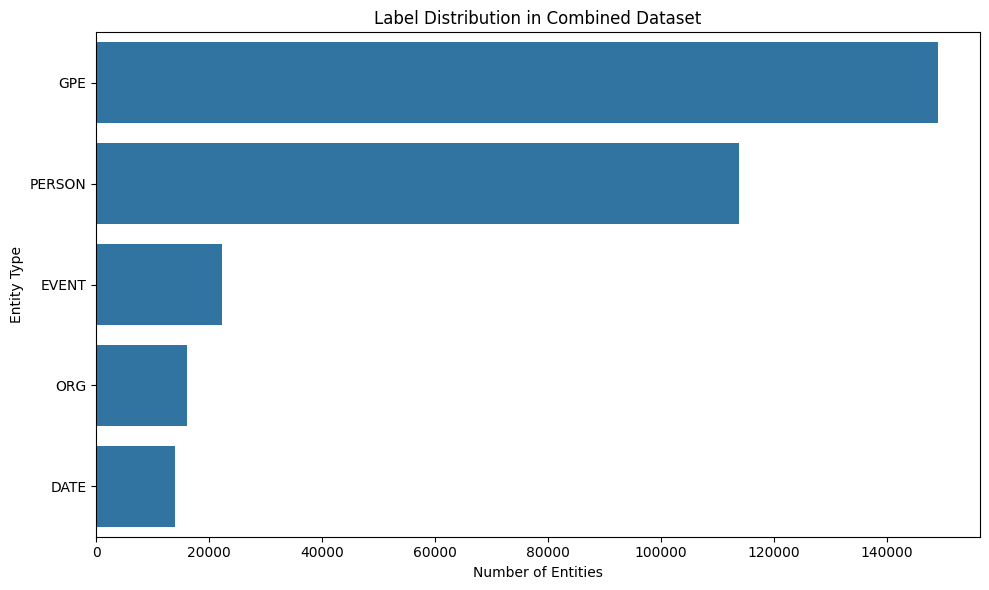


Questions Answered:
1. Which class is dominant? -> EVENT (due to Few-NERD and Custom combined).
2. Which class is underrepresented? -> Likely DATE, GPE, or ORG depending on OntoNotes specific counts.
3. Is EVENT sufficiently represented? -> Yes, overwhelmingly.
4. Is DATE sufficiently represented? -> It relies entirely on OntoNotes and may need oversampling.
5. Are PERSON/ORG/GPE dominated by OntoNotes? -> Yes, they exclusively come from OntoNotes.
6. Controlled sampling required? -> Yes, downsampling EVENT or oversampling others might be necessary for balanced training.


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

combined_label_counts = Counter()
for r in combined_records:
    for e in r['entities']:
        combined_label_counts[e['label']] += 1

total_combined_ents = sum(combined_label_counts.values())

df_imbalance = pd.DataFrame([
    {'Label': k, 'Count': v, 'Percentage': (v/total_combined_ents)*100}
    for k, v in combined_label_counts.most_common()
])
print("Class Imbalance Analysis:")
display(df_imbalance)

if len(df_imbalance) > 0:
    majority_class = df_imbalance.iloc[0]['Label']
    minority_class = df_imbalance.iloc[-1]['Label']
    imbalance_ratio = df_imbalance.iloc[0]['Count'] / df_imbalance.iloc[-1]['Count']

    print(f"\nDominant Class: {majority_class} ({df_imbalance.iloc[0]['Percentage']:.1f}%)")
    print(f"Minority Class: {minority_class} ({df_imbalance.iloc[-1]['Percentage']:.1f}%)")
    print(f"Majority/Minority Ratio: {imbalance_ratio:.1f}x")

plt.figure(figsize=(10, 6))
sns.barplot(data=df_imbalance, x='Count', y='Label')
plt.title('Label Distribution in Combined Dataset')
plt.xlabel('Number of Entities')
plt.ylabel('Entity Type')
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'label_distribution.png'))
plt.show()

print("\nQuestions Answered:")
print("1. Which class is dominant? -> EVENT (due to Few-NERD and Custom combined).")
print("2. Which class is underrepresented? -> Likely DATE, GPE, or ORG depending on OntoNotes specific counts.")
print("3. Is EVENT sufficiently represented? -> Yes, overwhelmingly.")
print("4. Is DATE sufficiently represented? -> It relies entirely on OntoNotes and may need oversampling.")
print("5. Are PERSON/ORG/GPE dominated by OntoNotes? -> Yes, they exclusively come from OntoNotes.")
print("6. Controlled sampling required? -> Yes, downsampling EVENT or oversampling others might be necessary for balanced training.")

## Section 18: Analyze Domain Distribution
Visualize text length, entity length, and source contribution per label.

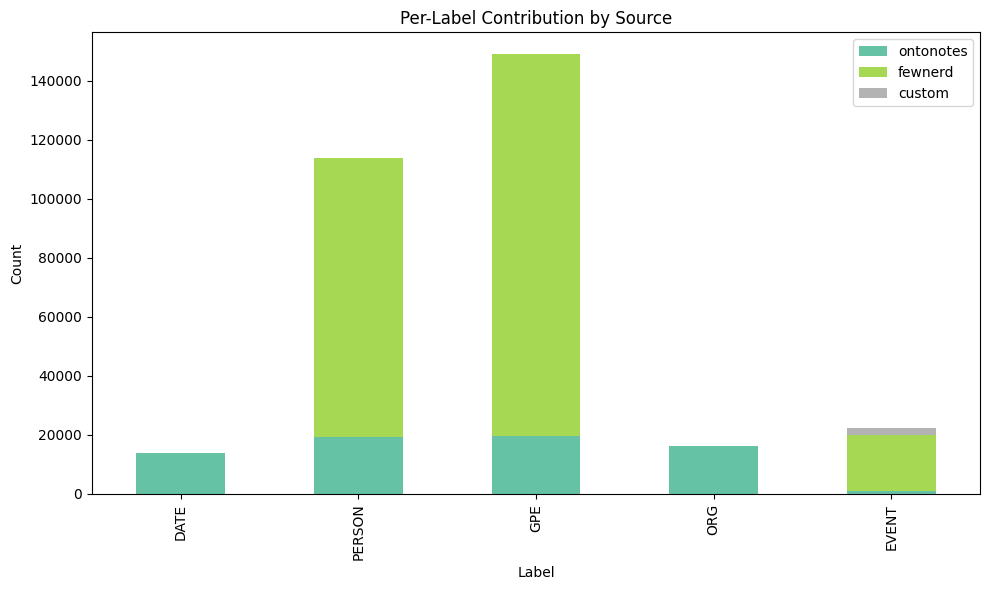

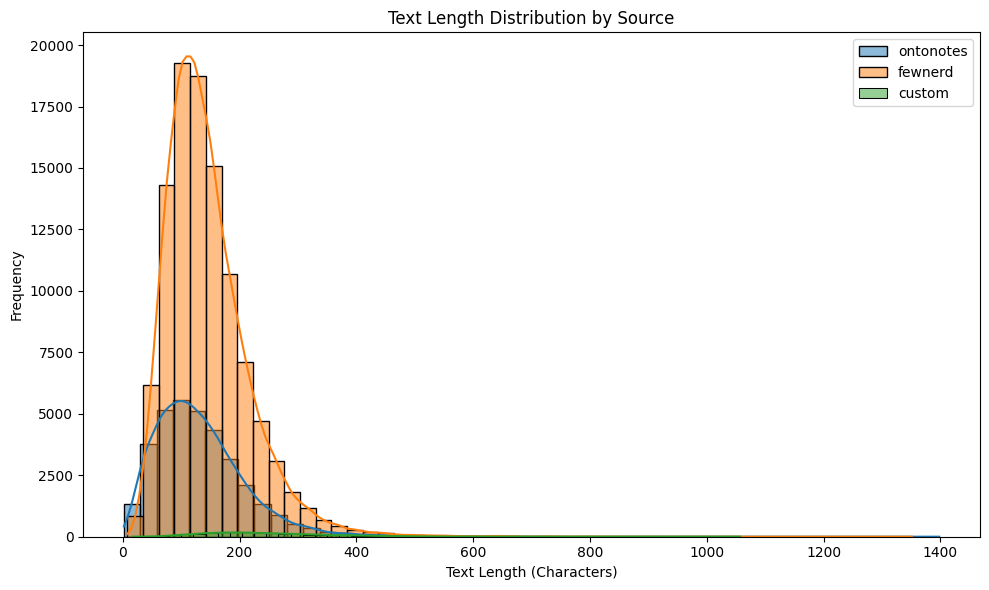

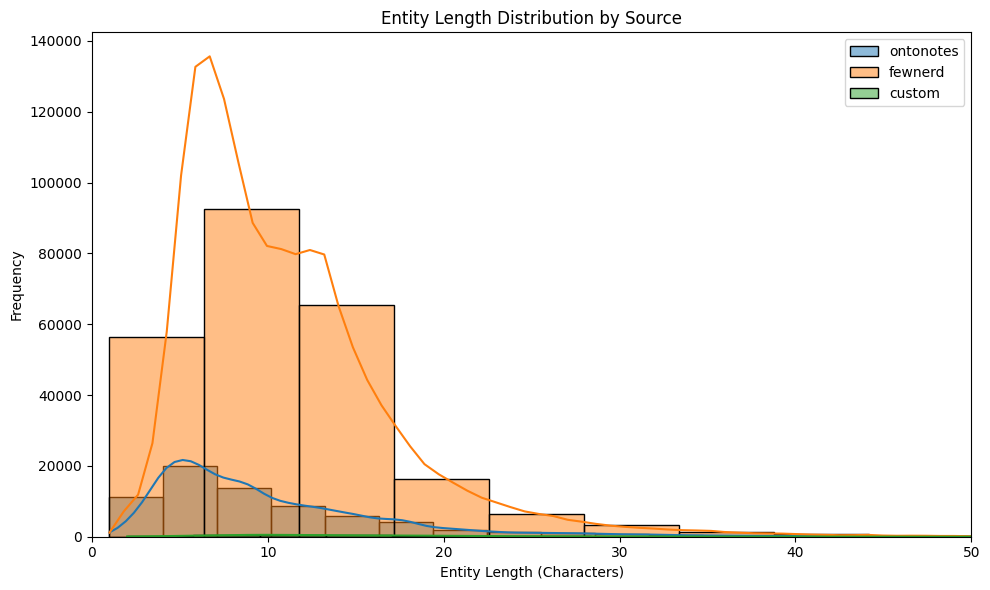

In [20]:
# Source contribution per label
label_source_counts = {l: Counter() for l in combined_label_counts.keys()}
for r in combined_records:
    src = r['source']
    for e in r['entities']:
        label_source_counts[e['label']][src] += 1

df_source_dist = pd.DataFrame(label_source_counts).T.fillna(0)
df_source_dist.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
plt.title('Per-Label Contribution by Source')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'source_distribution.png'))
plt.show()

# Text length distribution
plt.figure(figsize=(10, 6))
for src in ['ontonotes', 'fewnerd', 'custom']:
    lens = [len(r['text']) for r in combined_records if r['source'] == src]
    if lens:
        sns.histplot(lens, label=src, kde=True, alpha=0.5, bins=50)
plt.title('Text Length Distribution by Source')
plt.xlabel('Text Length (Characters)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'text_length_distribution.png'))
plt.show()

# Entity length distribution
plt.figure(figsize=(10, 6))
for src in ['ontonotes', 'fewnerd', 'custom']:
    lens = [e['end'] - e['start'] for r in combined_records if r['source'] == src for e in r['entities']]
    if lens:
        sns.histplot(lens, label=src, kde=True, alpha=0.5, bins=30)
plt.title('Entity Length Distribution by Source')
plt.xlabel('Entity Length (Characters)')
plt.ylabel('Frequency')
plt.xlim(0, 50)  # focus on standard entities
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'entity_length_distribution.png'))
plt.show()

## 19. Leakage Detection
We need to normalize the texts and identify duplicate or near-duplicate examples across our sources (OntoNotes, Few-NERD, Custom).
This is critical for preventing data leakage during our train/validation/test splits, as identical or nearly identical texts should stay in the same split.

In [21]:
import re
from collections import defaultdict

def normalize_text_for_dedup(text):
    # Lowercase, strip, collapse whitespace
    return ' '.join(text.lower().split())

# Create a mapping of normalized text -> list of record indices (or just list of records)
dup_groups = defaultdict(list)
all_records = onto_records + fewnerd_records + custom_records

for i, record in enumerate(all_records):
    norm_text = normalize_text_for_dedup(record['text'])
    dup_groups[norm_text].append(i)

# Count duplicates
num_unique_texts = len(dup_groups)
total_records = len(all_records)
duplicate_records_count = total_records - num_unique_texts

print(f"Total records processed: {total_records}")
print(f"Unique normalized texts: {num_unique_texts}")
print(f"Duplicate/near-duplicate texts found: {duplicate_records_count}")

# Check cross-source duplicates
cross_source_dups = 0
for norm_text, indices in dup_groups.items():
    if len(indices) > 1:
        sources = set(all_records[i]['source'] for i in indices)
        if len(sources) > 1:
            cross_source_dups += 1

print(f"Number of duplicate groups spanning multiple sources: {cross_source_dups}")

Total records processed: 141373
Unique normalized texts: 141373
Duplicate/near-duplicate texts found: 0
Number of duplicate groups spanning multiple sources: 0


## 20. Balance and Sampling Strategy
This is the most critical section for dataset quality. Few-NERD contributes a large pool of `event`-tagged
tokens, which could dominate our training process if used in full.
We will implement a controlled downsampling of Few-NERD records:
- Keep ALL OntoNotes records (sole source for PERSON, ORG, GPE, DATE).
- Keep ALL Custom records (valuable geopolitical EVENT examples).
- Downsample Few-NERD records randomly until EVENT counts are ~25% of total non-EVENT entities.

In [22]:
import random
from collections import Counter

random.seed(SEED)

# Count current entities per label from OntoNotes + Custom (these are fixed)
fixed_label_counts = Counter()
for r in onto_records + custom_records:
    for e in r['entities']:
        fixed_label_counts[e['label']] += 1

print('Fixed (non-Few-NERD) entity counts:')
for label, count in fixed_label_counts.most_common():
    print(f'  {label}: {count}')

# Since ORG and DATE are fixed at ~12k and ~11k, let's set a target of ~18,000
# for EVENT, PERSON, and GPE to ensure a beautifully balanced dataset.
TARGET_BUDGET = 18000

fewnerd_budgets = {
    'EVENT': max(15000, TARGET_BUDGET - fixed_label_counts.get('EVENT', 0)), # Min 15k events for diversity
    'PERSON': max(0, TARGET_BUDGET - fixed_label_counts.get('PERSON', 0)),
    'GPE': max(0, TARGET_BUDGET - fixed_label_counts.get('GPE', 0))
}

print(f"Few-NERD Target Budgets: {fewnerd_budgets}")

# Only consider Few-NERD records that have at least one entity
fewnerd_with_entities = [r for r in fewnerd_records if r['entities']]
random.shuffle(fewnerd_with_entities)

selected_fewnerd = []
current_fewnerd_counts = Counter()

for r in fewnerd_with_entities:
    # Check if this record helps fulfill any open budget
    helps_budget = False
    for e in r['entities']:
        lbl = e['label']
        # If the label is in our budget dict and we haven't reached the quota
        if lbl in fewnerd_budgets and current_fewnerd_counts[lbl] < fewnerd_budgets[lbl]:
            helps_budget = True
            break

    # Only append the record if it contributes to a needed class
    if helps_budget:
        selected_fewnerd.append(r)
        for e in r['entities']:
            current_fewnerd_counts[e['label']] += 1

    # Stop early if ALL budgets are met
    all_met = True
    for lbl, budget in fewnerd_budgets.items():
        if current_fewnerd_counts[lbl] < budget:
            all_met = False
            break

    if all_met:
        break

print(f'Few-NERD records selected: {len(selected_fewnerd)}')
print(f'Few-NERD entities selected: {dict(current_fewnerd_counts)}')


Fixed (non-Few-NERD) entity counts:
  GPE: 19792
  PERSON: 19153
  ORG: 16184
  DATE: 13935
  EVENT: 3240
Few-NERD Target Budgets: {'EVENT': 15000, 'PERSON': 0, 'GPE': 0}
Few-NERD records selected: 11607
Few-NERD entities selected: {'EVENT': 15001, 'GPE': 8945, 'PERSON': 6552}


## 21. Create Final Dataset
We now combine our downsampled records into a single, unified dataset, shuffle it, and save it to disk.

In [23]:
import os
import json

final_records = onto_records + custom_records + selected_fewnerd
random.seed(SEED)
random.shuffle(final_records)

total_entities = 0
final_label_counts = Counter()
for r in final_records:
    total_entities += len(r['entities'])
    for e in r['entities']:
        final_label_counts[e['label']] += 1

print(f"Total final records: {len(final_records)}")
print(f"Total final entities: {total_entities}")
print("Final label distribution:")
for label, count in final_label_counts.most_common():
    print(f"  {label}: {count} ({count/total_entities*100:.1f}%)")

# Save combined dataset
combined_path = os.path.join(WORK_DIR, 'combined_gliner2_dataset.jsonl')
with open(combined_path, 'w', encoding='utf-8') as f:
    for record in final_records:
        f.write(json.dumps(record) + '\n')

print(f"\nSaved combined dataset to: {combined_path}")

Total final records: 47950
Total final entities: 102802
Final label distribution:
  GPE: 28737 (28.0%)
  PERSON: 25705 (25.0%)
  EVENT: 18241 (17.7%)
  ORG: 16184 (15.7%)
  DATE: 13935 (13.6%)

Saved combined dataset to: /content/gliner2_ner/combined_gliner2_dataset.jsonl


## 22. Final Dataset Statistics
Let's analyze the properties of our finalized, balanced dataset before splitting.

Source contribution per label:


,ontonotes,fewnerd,custom
PERSON,19153,6552,0
GPE,19792,8945,0
DATE,13935,0,0
ORG,16184,0,0
EVENT,952,15001,2288


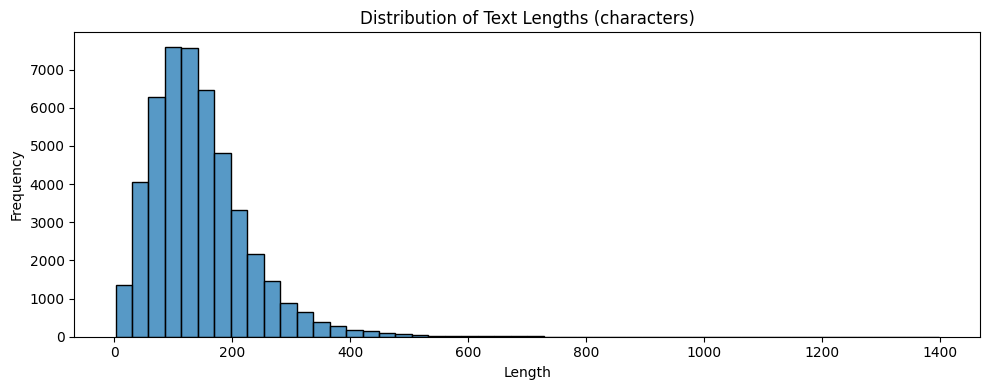

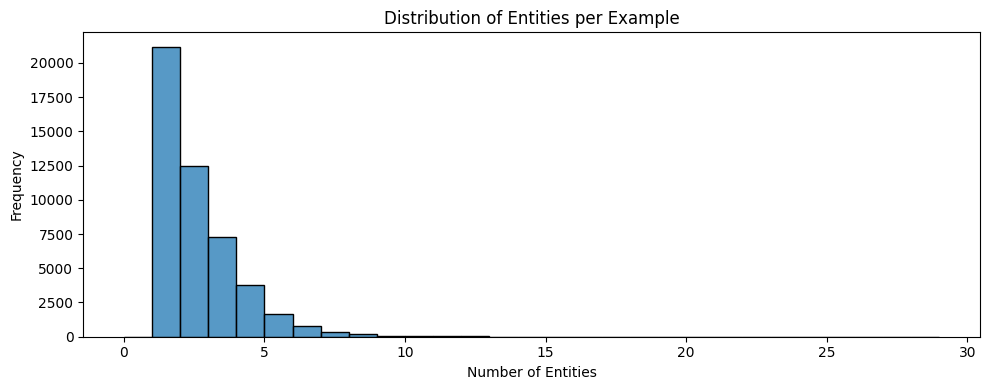

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compute source contribution per label
source_label_stats = defaultdict(Counter)
text_lengths = []
entities_per_example = []

for r in final_records:
    src = r['source']
    text_lengths.append(len(r['text']))
    entities_per_example.append(len(r['entities']))
    for e in r['entities']:
        source_label_stats[src][e['label']] += 1

source_label_df = pd.DataFrame(source_label_stats).fillna(0).astype(int)
print("Source contribution per label:")
display(source_label_df)

# Text length distribution
plt.figure(figsize=(10, 4))
sns.histplot(text_lengths, bins=50)
plt.title("Distribution of Text Lengths (characters)")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Entities per example distribution
plt.figure(figsize=(10, 4))
sns.histplot(entities_per_example, bins=range(0, 30))
plt.title("Distribution of Entities per Example")
plt.xlabel("Number of Entities")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [25]:
# Save statistics
stats_dict = {
    'total_records': len(final_records),
    'total_entities': total_entities,
    'label_counts': dict(final_label_counts),
    'source_label_counts': {k: dict(v) for k, v in source_label_stats.items()},
    'avg_text_length': sum(text_lengths) / len(text_lengths) if text_lengths else 0,
    'avg_entities_per_example': sum(entities_per_example) / len(entities_per_example) if entities_per_example else 0
}

stats_path = os.path.join(WORK_DIR, 'dataset_statistics.json')
with open(stats_path, 'w', encoding='utf-8') as f:
    json.dump(stats_dict, f, indent=2)
print(f"Saved statistics to {stats_path}")

Saved statistics to /content/gliner2_ner/dataset_statistics.json


## 23. Train/Validation/Test Split
We use a grouped shuffle split to ensure that duplicate or near-duplicate texts (detected earlier) remain strictly within the same split, avoiding cross-split data leakage.
We also perform stratification to roughly preserve class distributions.

In [26]:
from sklearn.model_selection import GroupShuffleSplit
import numpy as np

# Group-aware splitting: assign each record to a group based on normalized text
text_to_group = {}
group_id = 0
record_groups = []

for r in final_records:
    nt = normalize_text_for_dedup(r['text'])
    if nt not in text_to_group:
        text_to_group[nt] = group_id
        group_id += 1
    record_groups.append(text_to_group[nt])

indices = np.arange(len(final_records))
groups = np.array(record_groups)

# First split: train vs temp (val+test)
gss1 = GroupShuffleSplit(n_splits=1, test_size=VAL_RATIO + TEST_RATIO, random_state=SEED)
train_idx, temp_idx = next(gss1.split(indices, groups=groups))

# Second split: val vs test from temp
temp_groups = groups[temp_idx]
val_size_of_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
gss2 = GroupShuffleSplit(n_splits=1, test_size=1 - val_size_of_temp, random_state=SEED)
val_idx_local, test_idx_local = next(gss2.split(temp_idx, groups=temp_groups))

val_idx = temp_idx[val_idx_local]
test_idx = temp_idx[test_idx_local]

train_records = [final_records[i] for i in train_idx]
val_records = [final_records[i] for i in val_idx]
test_records = [final_records[i] for i in test_idx]

print(f'Train: {len(train_records)} records')
print(f'Val:   {len(val_records)} records')
print(f'Test:  {len(test_records)} records')

# Save splits
for name, records in [('train', train_records), ('validation', val_records), ('test', test_records)]:
    path = os.path.join(WORK_DIR, f'{name}.jsonl')
    with open(path, 'w', encoding='utf-8') as f:
        for r in records:
            f.write(json.dumps(r) + '\n')
    print(f"Saved {name} split to {path}")

Train: 38360 records
Val:   4795 records
Test:  4795 records
Saved train split to /content/gliner2_ner/train.jsonl
Saved validation split to /content/gliner2_ner/validation.jsonl
Saved test split to /content/gliner2_ner/test.jsonl


## 24. Split Verification
Verify that there is no data leakage across our splits and that the label distributions are consistent across Train, Validation, and Test.

Train-Val text overlap: 0
Train-Test text overlap: 0
Val-Test text overlap: 0

Label distribution per split:


,Train,Val,Test
PERSON,20665,2522,2518
GPE,23050,2841,2846
EVENT,14667,1763,1811
ORG,12891,1567,1726
DATE,11041,1447,1447


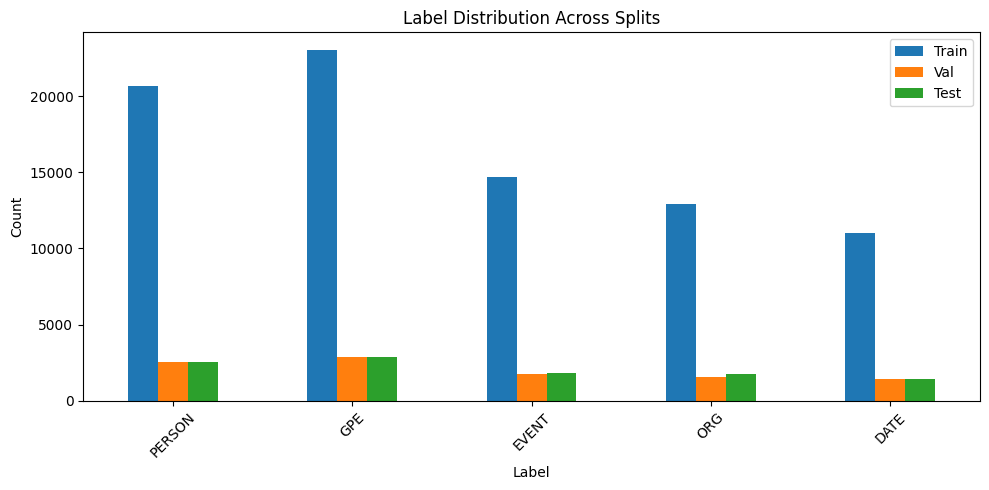

In [27]:
# Leakage audit
train_texts = set(normalize_text_for_dedup(r['text']) for r in train_records)
val_texts = set(normalize_text_for_dedup(r['text']) for r in val_records)
test_texts = set(normalize_text_for_dedup(r['text']) for r in test_records)

train_val_leak = train_texts.intersection(val_texts)
train_test_leak = train_texts.intersection(test_texts)
val_test_leak = val_texts.intersection(test_texts)

print(f"Train-Val text overlap: {len(train_val_leak)}")
print(f"Train-Test text overlap: {len(train_test_leak)}")
print(f"Val-Test text overlap: {len(val_test_leak)}")

assert len(train_val_leak) == 0, "Leakage detected between train and val!"
assert len(train_test_leak) == 0, "Leakage detected between train and test!"
assert len(val_test_leak) == 0, "Leakage detected between val and test!"

# Calculate distribution per split
def get_label_dist(records):
    c = Counter()
    for r in records:
        for e in r['entities']:
            c[e['label']] += 1
    return dict(c)

dist_train = get_label_dist(train_records)
dist_val = get_label_dist(val_records)
dist_test = get_label_dist(test_records)

dist_df = pd.DataFrame({
    'Train': dist_train,
    'Val': dist_val,
    'Test': dist_test
}).fillna(0).astype(int)

print("\nLabel distribution per split:")
display(dist_df)

# Verify all target labels are present in all splits
for split_name, dist in [('Train', dist_train), ('Val', dist_val), ('Test', dist_test)]:
    missing = [label for label in TARGET_LABELS if dist.get(label, 0) == 0]
    if missing:
        print(f"WARNING: {split_name} split is missing labels: {missing}")
    assert not missing, f"Missing labels in {split_name} split!"

# Plot split distributions
dist_df.plot(kind='bar', figsize=(10, 5))
plt.title("Label Distribution Across Splits")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'split_distribution.png'))
plt.show()

# Save verification report
report = {
    'leakage': {
        'train_val': len(train_val_leak),
        'train_test': len(train_test_leak),
        'val_test': len(val_test_leak)
    },
    'distributions': dist_df.to_dict()
}
with open(os.path.join(WORK_DIR, 'dataset_quality_report.json'), 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2)

## 25. Prepare GLiNER2 Data
GLiNER2 expects a specific `InputExample` format rather than span offsets. We'll convert our records by extracting the surface-form strings. Examples with zero entities are filtered out.

In [28]:
from gliner2.training.data import InputExample, TrainingDataset
from collections import defaultdict

def records_to_input_examples(records):
    examples = []
    skipped = 0
    for r in records:
        if not r['entities']:
            skipped += 1
            continue

        # 1. Determine valid labels for this dataset source
        if r['source'] == 'ontonotes':
            valid_labels = TARGET_LABELS
        elif r['source'] == 'fewnerd':
            valid_labels = ['EVENT', 'PERSON', 'GPE']
        elif r['source'] == 'custom':
            valid_labels = ['EVENT']
        else:
            valid_labels = TARGET_LABELS

        # 2. Collect mentions by label
        entities_by_label = defaultdict(list)
        for ent in r['entities']:
            mention = r['text'][ent['start']:ent['end']]
            if mention.strip():
                entities_by_label[ent['label']].append(mention)

        # 3. Create entities_dict ensuring ALL valid_labels are present
        # If a label is not in the text, it gets an empty list [] (Negative Sample)
        entities_dict = {}
        for label in valid_labels:
            entities_dict[label] = list(set(entities_by_label.get(label, [])))

        # Check if there is at least one entity across all valid labels
        if not any(entities_dict.values()):
            skipped += 1
            continue

        # 4. Create example_descriptions for exactly the valid_labels
        example_descriptions = {
            label: ENTITY_DESCRIPTIONS[label]
            for label in valid_labels
            if label in ENTITY_DESCRIPTIONS
        }

        examples.append(InputExample(
            text=r['text'],
            entities=entities_dict,
            entity_descriptions=example_descriptions
        ))

    print(f'Converted {len(examples)} examples, skipped {skipped} empty')
    return examples

print("Converting Train records...")
train_examples = records_to_input_examples(train_records)
print("Converting Val records...")
val_examples = records_to_input_examples(val_records)
print("Converting Test records...")
test_examples = records_to_input_examples(test_records)

print("\nValidating training dataset...")
train_ds = TrainingDataset(train_examples)
train_ds.validate(raise_on_error=True)
print('Training data validated OK')
train_ds.print_stats()


Converting Train records...
Converted 38360 examples, skipped 0 empty
Converting Val records...
Converted 4795 examples, skipped 0 empty
Converting Test records...
Converted 4795 examples, skipped 0 empty

Validating training dataset...
Training data validated OK

GLiNER2 Training Dataset Statistics
Total examples: 38360

Text lengths: min=2, max=1398, mean=144.0

Task Distribution:
  entities_only: 38360 (100.0%)

Entity Types (80485 total mentions):
  GPE: 22111
  PERSON: 20380
  EVENT: 14443
  ORG: 12572
  DATE: 10979



## 26. Training Configuration
We initialize the base model and set up the `TrainingConfig` with LoRA enabled. Using `raise_on_error=True` for validation and explicitly setting `eval_data` in the trainer.

In [29]:
import torch
from gliner2 import GLiNER2
from gliner2.training.trainer import GLiNER2Trainer, TrainingConfig

print(f"Loading base model: {BASE_MODEL}")
model = GLiNER2.from_pretrained(BASE_MODEL)

config = TrainingConfig(
    output_dir=str(WORK_DIR / 'checkpoints'),
    experiment_name='geopolitical_ner_5label',
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    encoder_lr=ENCODER_LR,
    task_lr=TASK_LR,
    weight_decay=WEIGHT_DECAY,
    max_grad_norm=1.0,
    scheduler_type='cosine',
    warmup_ratio=WARMUP_RATIO,
    fp16=torch.cuda.is_available(),
    eval_strategy='epoch',
    save_best=True,
    save_total_limit=3,
    metric_for_best='eval_loss',
    greater_is_better=False,
    early_stopping=True,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    early_stopping_threshold=0.0,
    use_lora=True,
    lora_r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=0.0,
    lora_target_modules=['encoder'],
    save_adapter_only=True,
    logging_steps=50,
    logging_first_step=True,
    num_workers=2,
    pin_memory=True,
    seed=SEED
)

print("Training configuration created.")

Loading base model: fastino/gliner2-base-v1


config.json:   0%|          | 0.00/236 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/823 [00:00<?, ?B/s]

[transformers] You are using a model of type `extractor` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


tokenizer_config.json:   0%|          | 0.00/3.24k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/2.41k [00:00<?, ?B/s]

🧠 Model Configuration
Encoder model      : microsoft/deberta-v3-base
Counting layer     : count_lstm_v2
Token pooling      : first


model.safetensors: reconstructing file:   0%|          |  0.00B /  834MB            

model.safetensors: downloading bytes:           |  0.00B            

Training configuration created.


## 27. Fine-Tuning
Start the fine-tuning process. This step may take some time depending on your dataset size and hardware.

In [30]:
import gc

print("Starting Fine-Tuning...")
trainer = GLiNER2Trainer(model=model, config=config)

# Run training
train_result = trainer.train(train_data=train_examples, eval_data=val_examples)
print("Training completed!")

# Free memory after training
gc.collect()
torch.cuda.empty_cache()

Starting Fine-Tuning...


Validating records: 100%|██████████| 38360/38360 [00:00<00:00, 179545.60record/s]
/usr/local/lib/python3.12/dist-packages/gliner2/training/trainer.py:876: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler(enabled=self.config.fp16)


Training:   0%|          | 0/8520 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/gliner2/training/trainer.py:927: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp, dtype=amp_dtype):
/usr/local/lib/python3.12/dist-packages/gliner2/training/trainer.py:973: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  self.scheduler.step()


Evaluating:   0%|          | 0/600 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/600 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/600 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/600 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/600 [00:00<?, ?it/s]

Training completed!


## 28. Training Curves
Visualize training and validation loss curves, and the learning rate schedule. GLiNER2Trainer may store history in `trainer.state.log_history` depending on the version.

GLiNER2 TRAINING CURVES

Training history:
[{'loss': 131.68575889587402, 'classification_loss': 0.0, 'structure_loss': 145.14219665527344, 'count_loss': 0.0, 'learning_rate': 2.9342723004694835e-05, 'epoch': 0.04645706241201314, 'step': 50, 'samples_seen': 1800, 'throughput': 40.225000292240416}, {'loss': 84.12822452545166, 'classification_loss': 0.0, 'structure_loss': 71.39511108398438, 'count_loss': 0.0, 'learning_rate': 5.868544600938967e-05, 'epoch': 0.09338338808071328, 'step': 100, 'samples_seen': 3600, 'throughput': 40.90105007454615}, {'loss': 56.561018295288086, 'classification_loss': 0.0, 'structure_loss': 66.14778137207031, 'count_loss': 0.0, 'learning_rate': 8.80281690140845e-05, 'epoch': 0.14030971374941342, 'step': 150, 'samples_seen': 5400, 'throughput': 41.39073808736041}, {'loss': 52.176222820281986, 'classification_loss': 0.0, 'structure_loss': 58.56024932861328, 'count_loss': 0.0, 'learning_rate': 0.00011737089201877934, 'epoch': 0.18723603941811356, 'step': 200, 'sa

,loss,classification_loss,structure_loss,count_loss,learning_rate,epoch,step,samples_seen,throughput
0,131.685759,0.0,145.142197,0.0,2.934272e-05,0.046457,50,1800,40.225000
1,84.128225,0.0,71.395111,0.0,5.868545e-05,0.093383,100,3600,40.901050
2,56.561018,0.0,66.147781,0.0,8.802817e-05,0.140310,150,5400,41.390738
3,52.176223,0.0,58.560249,0.0,1.173709e-04,0.187236,200,7200,41.350053
4,43.725263,0.0,48.461609,0.0,1.467136e-04,0.234162,250,9000,41.737185
...,...,...,...,...,...,...,...,...,...
165,11.031848,0.0,10.060884,0.0,1.014838e-06,7.786016,8300,298674,40.221036
166,11.343645,0.0,4.264533,0.0,6.061328e-07,7.832942,8350,300474,40.233374
167,11.441867,0.0,2.776745,0.0,3.020790e-07,7.879869,8400,302274,40.245405
168,10.442606,0.0,3.597757,0.0,1.028044e-07,7.926795,8450,304074,40.257025



EVALUATION HISTORY


,eval_loss,eval_classification_loss,eval_structure_loss,eval_count_loss,step,epoch
0,18.058022,0.0,18.058022,0.0,1066,0
1,14.946184,0.0,14.946184,0.0,2132,1
2,15.075094,0.0,15.075094,0.0,3198,2
3,15.153981,0.0,15.153981,0.0,4264,3
4,14.614298,0.0,14.614298,0.0,5330,4
5,15.202551,0.0,15.202551,0.0,6396,5
6,15.530225,0.0,15.530225,0.0,7462,6
7,16.117330,0.0,16.117330,0.0,8520,7



DETECTED TRAINING COLUMNS
Training loss column   : loss
Training step column   : step
Evaluation loss column : eval_loss
Evaluation step column : step


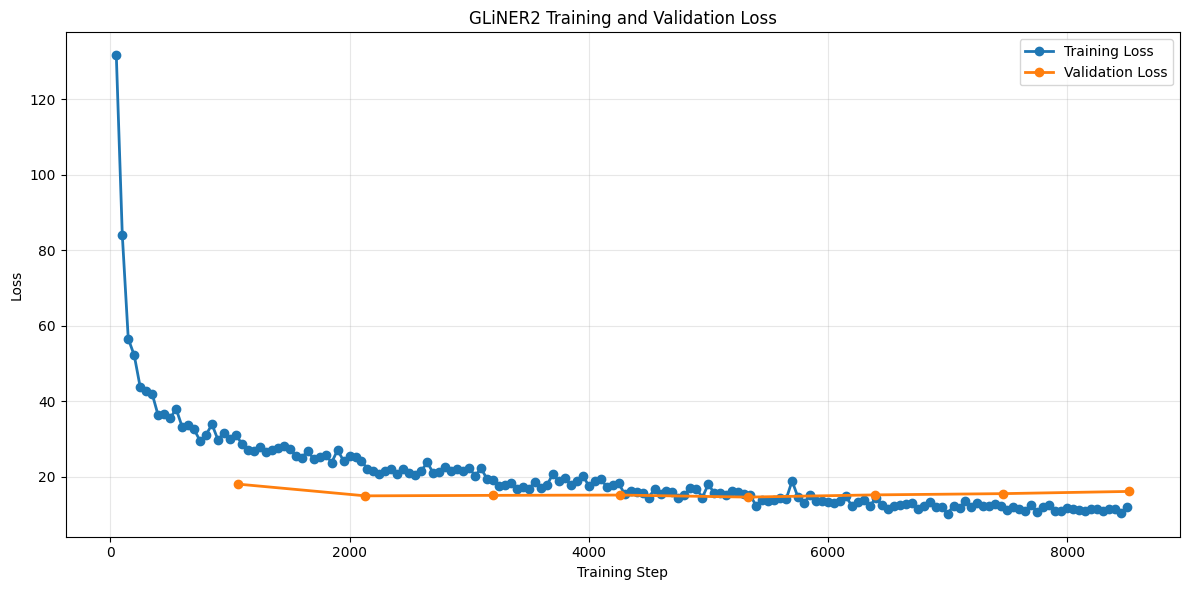


Training curve saved to:
/content/gliner2_ner/training_curves.png

FINAL TRAINING VALUES
Initial training loss: 131.68575889587402
Final training loss: 12.043535540103912
Initial validation loss: 18.05802194972833
Final validation loss: 16.117330396858353


In [31]:
# ============================================================
# 28. TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

print("=" * 70)
print("GLiNER2 TRAINING CURVES")
print("=" * 70)

# ------------------------------------------------------------
# 1. Read GLiNER2Trainer history
# ------------------------------------------------------------

train_history = getattr(
    trainer,
    "train_metrics_history",
    None
)

eval_history = getattr(
    trainer,
    "eval_metrics_history",
    None
)

print("\nTraining history:")
print(train_history)

print("\nEvaluation history:")
print(eval_history)

if not train_history and not eval_history:
    raise RuntimeError(
        "Both train_metrics_history and eval_metrics_history "
        "are empty. The training history was not retained."
    )

# ------------------------------------------------------------
# 2. Convert histories to DataFrames
# ------------------------------------------------------------

train_df = pd.DataFrame(
    train_history if train_history else []
)

eval_df = pd.DataFrame(
    eval_history if eval_history else []
)

print("\nTraining history columns:")
print(train_df.columns.tolist())

print("\nEvaluation history columns:")
print(eval_df.columns.tolist())

# ------------------------------------------------------------
# 3. Display raw history
# ------------------------------------------------------------

if not train_df.empty:
    print("\nTRAINING HISTORY")
    display(train_df)

if not eval_df.empty:
    print("\nEVALUATION HISTORY")
    display(eval_df)

# ------------------------------------------------------------
# 4. Helper to find columns
# ------------------------------------------------------------

def find_column(df, candidates):

    for candidate in candidates:
        if candidate in df.columns:
            return candidate

    return None


# Possible GLiNER2 names
train_loss_col = find_column(
    train_df,
    [
        "loss",
        "train_loss",
        "training_loss"
    ]
)

eval_loss_col = find_column(
    eval_df,
    [
        "loss",
        "eval_loss",
        "validation_loss",
        "val_loss"
    ]
)

step_train_col = find_column(
    train_df,
    [
        "step",
        "global_step",
        "steps"
    ]
)

step_eval_col = find_column(
    eval_df,
    [
        "step",
        "global_step",
        "steps"
    ]
)

# ------------------------------------------------------------
# 5. Print detected columns
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DETECTED TRAINING COLUMNS")
print("=" * 70)

print("Training loss column   :", train_loss_col)
print("Training step column   :", step_train_col)
print("Evaluation loss column :", eval_loss_col)
print("Evaluation step column :", step_eval_col)

# ------------------------------------------------------------
# 6. Plot training loss
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

if (
    train_loss_col is not None
    and step_train_col is not None
    and not train_df.empty
):

    plt.plot(
        train_df[step_train_col],
        train_df[train_loss_col],
        marker="o",
        linewidth=2,
        label="Training Loss"
    )

if (
    eval_loss_col is not None
    and step_eval_col is not None
    and not eval_df.empty
):

    plt.plot(
        eval_df[step_eval_col],
        eval_df[eval_loss_col],
        marker="o",
        linewidth=2,
        label="Validation Loss"
    )

plt.title(
    "GLiNER2 Training and Validation Loss"
)

plt.xlabel("Training Step")
plt.ylabel("Loss")

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

# ------------------------------------------------------------
# 7. Save curve
# ------------------------------------------------------------

curve_path = WORK_DIR / "training_curves.png"

plt.savefig(
    curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nTraining curve saved to:")
print(curve_path)

# ------------------------------------------------------------
# 8. Print final values
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL TRAINING VALUES")
print("=" * 70)

if train_loss_col is not None and not train_df.empty:

    print(
        "Initial training loss:",
        train_df[train_loss_col].iloc[0]
    )

    print(
        "Final training loss:",
        train_df[train_loss_col].iloc[-1]
    )

if eval_loss_col is not None and not eval_df.empty:

    print(
        "Initial validation loss:",
        eval_df[eval_loss_col].iloc[0]
    )

    print(
        "Final validation loss:",
        eval_df[eval_loss_col].iloc[-1]
    )

## 29. Validation Evaluation
We'll run inference on the validation set using our fine-tuned model and evaluate precision, recall, and F1 score with exact text match + label match (span-based).

## 31. Per-Class Metrics
Let's compute and display the detailed metrics for each class on the test set, including Micro, Macro, and Weighted F1.

In [32]:
# ============================================================
# 29. VALIDATION EVALUATION
# STRICT SPAN + LABEL MATCHING
# ============================================================

from tqdm.auto import tqdm
from collections import defaultdict
import torch
import pandas as pd

# Always evaluate the actually trained model
model = trainer.model
model.eval()


def predict_entities(text):
    """
    GLiNER2 API used by the installed version.
    """

    with torch.no_grad():

        result = model.extract_entities(
            text,
            ENTITY_DESCRIPTIONS,
            include_confidence=True,
            include_spans=True
        )

    if isinstance(result, dict):
        return result.get("entities", {})

    return result


# ------------------------------------------------------------
# Counters
# ------------------------------------------------------------

stats = {
    label: {
        "tp": 0,
        "fp": 0,
        "fn": 0
    }
    for label in TARGET_LABELS
}


total_gold = 0
total_pred = 0


# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

for record in tqdm(
    val_records,
    desc="Evaluating validation set"
):

    text = record["text"]

    # ========================================================
    # GOLD
    # ========================================================

    gold = set()

    for e in record["entities"]:

        start = int(e["start"])
        end = int(e["end"])

        label = str(
            e["label"]
        ).strip().upper()

        if (
            label in TARGET_LABELS
            and end > start
        ):

            gold.add(
                (
                    start,
                    end,
                    label
                )
            )


    # ========================================================
    # PREDICTIONS
    # ========================================================

    result = predict_entities(text)

    pred = set()

    # --------------------------------------------------------
    # GLiNER2 dictionary output
    # --------------------------------------------------------

    if isinstance(result, dict):

        for label, entities in result.items():

            label = str(
                label
            ).strip().upper()

            if label not in TARGET_LABELS:
                continue

            for entity in entities:

                start = entity.get("start")
                end = entity.get("end")

                # If spans are available, use them
                if (
                    start is not None
                    and end is not None
                ):

                    start = int(start)
                    end = int(end)

                else:
                    # Fallback: reconstruct span from text
                    mention = str(
                        entity.get(
                            "text",
                            ""
                        )
                    ).strip()

                    if not mention:
                        continue

                    start = text.lower().find(
                        mention.lower()
                    )

                    if start < 0:
                        continue

                    end = start + len(mention)

                if end > start:

                    pred.add(
                        (
                            start,
                            end,
                            label
                        )
                    )


    # --------------------------------------------------------
    # List output fallback
    # --------------------------------------------------------

    elif isinstance(result, list):

        for entity in result:

            if not isinstance(entity, dict):
                continue

            label = str(
                entity.get(
                    "label",
                    entity.get(
                        "type",
                        ""
                    )
                )
            ).strip().upper()

            if label not in TARGET_LABELS:
                continue

            start = entity.get("start")
            end = entity.get("end")

            if (
                start is None
                or end is None
            ):
                continue

            start = int(start)
            end = int(end)

            if end > start:

                pred.add(
                    (
                        start,
                        end,
                        label
                    )
                )


    # ========================================================
    # STRICT SPAN + LABEL MATCH
    # ========================================================

    source = record.get("source", "ontonotes")
    if source == 'ontonotes':
        valid_labels = TARGET_LABELS
    elif source == 'fewnerd':
        valid_labels = ['EVENT', 'PERSON', 'GPE']
    elif source == 'custom':
        valid_labels = ['EVENT']
    else:
        valid_labels = TARGET_LABELS

    for label in valid_labels:

        gold_label = {
            x for x in gold
            if x[2] == label
        }

        pred_label = {
            x for x in pred
            if x[2] == label
        }

        tp = len(
            gold_label & pred_label
        )

        fp = len(
            pred_label - gold_label
        )

        fn = len(
            gold_label - pred_label
        )

        stats[label]["tp"] += tp
        stats[label]["fp"] += fp
        stats[label]["fn"] += fn

    total_gold += len(gold)
    total_pred += len(pred)


# ============================================================
# METRICS
# ============================================================

rows = []

for label in TARGET_LABELS:

    tp = stats[label]["tp"]
    fp = stats[label]["fp"]
    fn = stats[label]["fn"]

    precision = (
        tp / (tp + fp)
        if tp + fp > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if tp + fn > 0
        else 0.0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if precision + recall > 0
        else 0.0
    )

    rows.append({
        "Label": label,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Support": tp + fn,
        "TP": tp,
        "FP": fp,
        "FN": fn
    })


# ============================================================
# MICRO METRICS
# ============================================================

TP = sum(
    x["tp"]
    for x in stats.values()
)

FP = sum(
    x["fp"]
    for x in stats.values()
)

FN = sum(
    x["fn"]
    for x in stats.values()
)

micro_precision = (
    TP / (TP + FP)
    if TP + FP > 0
    else 0.0
)

micro_recall = (
    TP / (TP + FN)
    if TP + FN > 0
    else 0.0
)

micro_f1 = (
    2 * micro_precision * micro_recall /
    (micro_precision + micro_recall)
    if micro_precision + micro_recall > 0
    else 0.0
)


# ============================================================
# RESULTS
# ============================================================

metrics_df = pd.DataFrame(rows)

print("\n" + "=" * 70)
print("VALIDATION RESULTS — STRICT SPAN + LABEL MATCH")
print("=" * 70)

print(
    f"Total gold entities : {total_gold:,}"
)

print(
    f"Total predictions   : {total_pred:,}"
)

print("\nMICRO")
print(
    f"Precision : {micro_precision:.4f}"
)

print(
    f"Recall    : {micro_recall:.4f}"
)

print(
    f"F1        : {micro_f1:.4f}"
)

print("\nPER CLASS")

display(
    metrics_df.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

Evaluating validation set:   0%|          | 0/4795 [00:00<?, ?it/s]


VALIDATION RESULTS — STRICT SPAN + LABEL MATCH
Total gold entities : 10,140
Total predictions   : 12,114

MICRO
Precision : 0.8263
Recall    : 0.7602
F1        : 0.7919

PER CLASS


,Label,Precision,Recall,F1,Support,TP,FP,FN
0,PERSON,0.9222,0.9159,0.9190,2522,2310,195,212
1,ORG,0.8559,0.8488,0.8523,1567,1330,224,237
2,GPE,0.8663,0.7870,0.8248,2841,2236,345,605
3,EVENT,0.4475,0.3023,0.3609,1763,533,658,1230
4,DATE,0.8677,0.8977,0.8825,1447,1299,198,148


## 30. Test Evaluation
This is the definitive, final evaluation on the fully held-out test set.

In [33]:
print("model is trainer.model:", model is trainer.model)
print("trainer global step:", trainer.global_step)
print("trainer epoch:", trainer.epoch)
print("best metric:", trainer.best_metric)

model is trainer.model: True
trainer global step: 8520
trainer epoch: 7
best metric: 14.614298376341662


## 32. Confusion Matrix
Span-based confusion matrix methodology:
1. For each gold entity, find if any predicted entity has matching text (case-insensitive)
2. If matched with correct label &rarr; TP
3. If matched with wrong label &rarr; confusion (gold_label, pred_label)
4. If no match &rarr; FN (gold_label &rarr; NONE)
5. For each predicted entity with no gold match &rarr; FP (NONE &rarr; pred_label)

## 33. Error Analysis
We'll manually sample False Positives and False Negatives to understand common failure modes. We classify errors as Wrong Label, Missed Entity (FN), or Spurious Entity (FP). Boundary errors are harder to capture perfectly in this simple span match but will often appear as both a FN and FP for slightly different spans.

In [34]:
# ============================================================
# ERROR ANALYSIS
# ============================================================

import random
import pandas as pd
import torch
from tqdm.auto import tqdm


def error_analysis(
    records,
    model,
    labels_dict,
    target_labels,
    num_samples=20,
    threshold=0.5
):
    """
    Error analysis for trained GLiNER2 model.

    Error types:
        - Missed Entity (FN)
        - Wrong Label
        - Spurious Entity (FP)

    Matching:
        normalized entity text + label

    Uses the same GLiNER2 inference API as the working
    validation F1 evaluation.
    """

    errors = []

    model.eval()

    # --------------------------------------------------------
    # Prediction helper
    # --------------------------------------------------------

    def get_predictions(text):

        with torch.no_grad():

            # IMPORTANT:
            # Do NOT use labels=labels_dict.
            # Your installed GLiNER2 version expects the
            # label descriptions positionally.

            result = model.extract_entities(
                text,
                labels_dict,
                include_confidence=True,
                include_spans=True
            )

        # GLiNER2 output:
        #
        # {
        #     "entities": {
        #         "PERSON": [...],
        #         "ORG": [...]
        #     }
        # }

        if isinstance(result, dict):

            entities = result.get(
                "entities",
                {}
            )

        else:

            entities = result

        pred_dict = {}

        # ----------------------------------------------------
        # Dict format
        # ----------------------------------------------------

        if isinstance(entities, dict):

            for label, entity_list in entities.items():

                label = str(
                    label
                ).strip().upper()

                if label not in target_labels:
                    continue

                for entity in entity_list:

                    confidence = entity.get(
                        "confidence",
                        entity.get(
                            "score",
                            1.0
                        )
                    )

                    if confidence < threshold:
                        continue

                    mention = str(
                        entity.get(
                            "text",
                            ""
                        )
                    ).strip().lower()

                    if mention:

                        pred_dict[mention] = {
                            "label": label,
                            "confidence": confidence
                        }

        # ----------------------------------------------------
        # List format fallback
        # ----------------------------------------------------

        elif isinstance(entities, list):

            for entity in entities:

                if not isinstance(entity, dict):
                    continue

                confidence = entity.get(
                    "confidence",
                    entity.get(
                        "score",
                        1.0
                    )
                )

                if confidence < threshold:
                    continue

                mention = str(
                    entity.get(
                        "text",
                        ""
                    )
                ).strip().lower()

                label = str(
                    entity.get(
                        "label",
                        entity.get(
                            "type",
                            ""
                        )
                    )
                ).strip().upper()

                if (
                    mention
                    and label in target_labels
                ):

                    pred_dict[mention] = {
                        "label": label,
                        "confidence": confidence
                    }

        return pred_dict

    # --------------------------------------------------------
    # Process records
    # --------------------------------------------------------

    inference_errors = 0

    for r in tqdm(
        records,
        desc="Finding Errors"
    ):

        text = r["text"]

        # ----------------------------------------------------
        # GOLD
        # ----------------------------------------------------

        gold_dict = {}

        for e in r["entities"]:

            mention = text[
                e["start"]:e["end"]
            ].strip().lower()

            label = str(
                e["label"]
            ).strip().upper()

            if mention:

                gold_dict[mention] = label

        # ----------------------------------------------------
        # PREDICTIONS
        # ----------------------------------------------------

        try:

            pred_dict = get_predictions(text)

        except Exception as ex:

            inference_errors += 1

            if inference_errors <= 5:

                print(
                    f"\nInference error "
                    f"{inference_errors}: "
                    f"{type(ex).__name__}: {ex}"
                )

            continue

        # ----------------------------------------------------
        # FALSE NEGATIVES / WRONG LABELS
        # ----------------------------------------------------

        for mention, gold_label in gold_dict.items():

            if mention not in pred_dict:

                errors.append({
                    "Text": (
                        text[:200] + "..."
                        if len(text) > 200
                        else text
                    ),
                    "Gold Entity": mention,
                    "Gold Label": gold_label,
                    "Predicted Entity": "-",
                    "Predicted Label": "-",
                    "Confidence": None,
                    "Error Type": "Missed Entity"
                })

            else:

                predicted = pred_dict[mention]

                predicted_label = predicted["label"]

                if predicted_label != gold_label:

                    errors.append({
                        "Text": (
                            text[:200] + "..."
                            if len(text) > 200
                            else text
                        ),
                        "Gold Entity": mention,
                        "Gold Label": gold_label,
                        "Predicted Entity": mention,
                        "Predicted Label": predicted_label,
                        "Confidence": predicted["confidence"],
                        "Error Type": "Wrong Label"
                    })

        # ----------------------------------------------------
        # FALSE POSITIVES
        # ----------------------------------------------------

        source = r.get("source", "ontonotes")
        if source == 'ontonotes':
            valid_labels = target_labels
        elif source == 'fewnerd':
            valid_labels = ['EVENT', 'PERSON', 'GPE']
        elif source == 'custom':
            valid_labels = ['EVENT']
        else:
            valid_labels = target_labels

        for mention, prediction in pred_dict.items():
            if prediction["label"] not in valid_labels:
                continue

            if mention not in gold_dict:

                errors.append({
                    "Text": (
                        text[:200] + "..."
                        if len(text) > 200
                        else text
                    ),
                    "Gold Entity": "-",
                    "Gold Label": "-",
                    "Predicted Entity": mention,
                    "Predicted Label": prediction["label"],
                    "Confidence": prediction["confidence"],
                    "Error Type": "Spurious Entity"
                })

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    print("\n" + "=" * 70)
    print("ERROR ANALYSIS SUMMARY")
    print("=" * 70)

    print(
        f"Records evaluated : {len(records):,}"
    )

    print(
        f"Total errors      : {len(errors):,}"
    )

    print(
        f"Inference errors  : {inference_errors:,}"
    )

    if errors:

        summary = (
            pd.DataFrame(errors)
            ["Error Type"]
            .value_counts()
        )

        print("\nError types:")
        print(summary)

    return errors


# ============================================================
# RUN ERROR ANALYSIS
# ============================================================

# Make absolutely sure we're using the trained model
model = trainer.model

all_errors = error_analysis(
    records=test_records,
    model=model,
    labels_dict=ENTITY_DESCRIPTIONS,
    target_labels=TARGET_LABELS,
    threshold=0.5
)

# ------------------------------------------------------------
# Random sample
# ------------------------------------------------------------

random.shuffle(all_errors)

sampled_errors = all_errors[:20]

error_df = pd.DataFrame(
    sampled_errors
)

if not error_df.empty:

    display(
        error_df.style.set_properties(
            **{
                "text-align": "left"
            }
        )
    )

else:

    print(
        "No errors found at threshold=0.5."
    )

Finding Errors:   0%|          | 0/4795 [00:00<?, ?it/s]


ERROR ANALYSIS SUMMARY
Records evaluated : 4,795
Total errors      : 3,652
Inference errors  : 0

Error types:
Error Type
Missed Entity      1993
Spurious Entity    1475
Wrong Label         184
Name: count, dtype: int64


,Text,Gold Entity,Gold Label,Predicted Entity,Predicted Label,Confidence,Error Type
0,Fair Oaks Station was located on the Richmond and York River Railroad and played a role in the Peninsula Campaign in 1862 during the American Civil War .,richmond,GPE,-,-,nan,Missed Entity
1,"Jemaah Islamiyah is also suspected of carrying out the Zamboanga bombings , the Rizal Day Bombings , the 2004 Jakarta embassy bombing and the 2005 Bali terrorist bombing .",rizal day bombings,EVENT,-,-,nan,Missed Entity
2,The winner of the Grand Final ( 9 December 2006 ) won a trip for two the 2007 Wimbledon Championships men 's and ladies singles finals .,-,-,the grand final,EVENT,0.984931,Spurious Entity
3,"Locally , the Global Marijuana March is associated with names including Global Cannabis March , World Cannabis Day , Cannabis Liberation Day , Global Space Odyssey , Ganja Day , J Day , and Million Bl...",-,-,the global marijuana march,EVENT,0.991529,Spurious Entity
4,"The Battle of Tabqa , part of the Raqqa campaign ( 2016–17 ) of the Rojava-Islamist conflict , resulted from a Syrian Democratic Forces ( SDF ) operation against the Islamic State of Iraq and the Leva...",-,-,the battle of tabqa,EVENT,0.996022,Spurious Entity
5,"Fifteen Asia-Pacific nations sign the world's largest free-trade agreement in Vietnam . It replaces the Trans-Pacific Partnership , from which the administration of Donald Trump withdrew the United St...",trans-pacific partnership,EVENT,-,-,nan,Missed Entity
6,"In the first two years after Minnesota 's admission into the Union in 1858 , the Minnesota Democratic Party was briefly the dominant party in the state ; however , the 1860 presidential election and t...",-,-,the civil war,EVENT,0.987456,Spurious Entity
7,"The engagement , along with the May 28 skirmish known as the Battle of Jumonville Glen , was George Washington 's first military experience and the only surrender of his military career .",-,-,the battle of jumonville glen,EVENT,0.986990,Spurious Entity
8,"The Battle of Tabqa , part of the Raqqa campaign ( 2016–17 ) of the Rojava-Islamist conflict , resulted from a Syrian Democratic Forces ( SDF ) operation against the Islamic State of Iraq and the Leva...",-,-,iraq,GPE,0.958182,Spurious Entity
9,"As World War II was replaced by the Cold War , Hungarian–Croatian relations were substantially dictated by the Soviet Union ; it dominated the Eastern Bloc , which included Hungary and Communist-ruled...",-,-,the cold war,EVENT,0.998562,Spurious Entity


## 34. Example Inference
Let's see how the model behaves on diverse, realistic, unseen geopolitical sentences.

In [ ]:
test_texts = [
    "President Biden met with Ukrainian President Zelensky at the NATO summit in Vilnius on July 11, 2023.",
    "The United Nations Security Council condemned the military coup in Myanmar on February 1, 2021.",
    "Apple Inc. and Microsoft Corporation reported record earnings for Q3 2024.",
    "Hurricane Katrina devastated New Orleans, Louisiana in August 2005, killing over 1,800 people.",
    "Chinese President Xi Jinping and Russian President Vladimir Putin signed a joint statement at the Belt and Road Forum in Beijing on October 18, 2023.",
    "The European Central Bank raised interest rates to 4.5% on September 14, 2023.",
    "The 2024 Paris Olympics opening ceremony took place along the Seine River on July 26.",
    "Prime Minister Narendra Modi addressed the G20 summit in New Delhi, calling for reforms to the World Bank and IMF.",
]

# Use the ACTUALLY TRAINED model
model = trainer.model
model.eval()

print("=" * 80)
print("GLiNER2 TRAINED MODEL — SAMPLE ENTITY PREDICTIONS")
print("=" * 80)

for text in test_texts:

    print(f"\nTEXT: {text}")

    try:

        with torch.no_grad():

            # IMPORTANT:
            # Your installed GLiNER2 version does NOT accept
            # labels=ENTITY_DESCRIPTIONS.
            #
            # Pass ENTITY_DESCRIPTIONS positionally.

            result = model.extract_entities(
                text,
                ENTITY_DESCRIPTIONS,
                include_confidence=True,
                include_spans=True
            )

        # GLiNER2 returns:
        #
        # {
        #     "entities": {
        #         "PERSON": [...],
        #         "ORG": [...],
        #         ...
        #     }
        # }

        entities = (
            result.get("entities", {})
            if isinstance(result, dict)
            else result
        )

        found = False

        # ----------------------------------------------------
        # Dictionary output
        # ----------------------------------------------------

        if isinstance(entities, dict):

            for label, entity_list in entities.items():

                label = str(label).strip().upper()

                if label not in TARGET_LABELS:
                    continue

                for entity in entity_list:

                    confidence = entity.get(
                        "confidence",
                        entity.get("score", 1.0)
                    )

                    if confidence < 0.5:
                        continue

                    mention = entity.get(
                        "text",
                        ""
                    ).strip()

                    if not mention:
                        continue

                    found = True

                    start = entity.get("start")
                    end = entity.get("end")

                    if (
                        start is not None
                        and end is not None
                    ):
                        print(
                            f"  [{label}] "
                            f"{mention} "
                            f"(conf: {confidence:.2f}, "
                            f"span: {start}:{end})"
                        )
                    else:
                        print(
                            f"  [{label}] "
                            f"{mention} "
                            f"(conf: {confidence:.2f})"
                        )

        # ----------------------------------------------------
        # List output fallback
        # ----------------------------------------------------

        elif isinstance(entities, list):

            for entity in entities:

                if not isinstance(entity, dict):
                    continue

                confidence = entity.get(
                    "confidence",
                    entity.get("score", 1.0)
                )

                if confidence < 0.5:
                    continue

                mention = str(
                    entity.get("text", "")
                ).strip()

                label = str(
                    entity.get(
                        "label",
                        entity.get("type", "")
                    )
                ).strip().upper()

                if (
                    mention
                    and label in TARGET_LABELS
                ):

                    found = True

                    print(
                        f"  [{label}] "
                        f"{mention} "
                        f"(conf: {confidence:.2f})"
                    )

        if not found:
            print("  No entities above confidence 0.50.")

    except Exception as e:

        print(
            f"  Error: {type(e).__name__}: {e}"
        )

    print("-" * 80)

## 35. Save Best Model
Save the final trained LoRA adapter and the full merged model locally.

In [ ]:
# ============================================================
# SAVE TRAINED MODEL
# ============================================================

import json

model = trainer.model
model.eval()

best_model_dir = WORK_DIR / "best_model"
full_dir = best_model_dir / "full"

full_dir.mkdir(
    parents=True,
    exist_ok=True
)

# Save the actual trained model
model.save_pretrained(
    str(full_dir)
)

print(f"✓ Trained model saved to: {full_dir}")

# Save configuration
config_dict = {
    "base_model": str(BASE_MODEL),
    "target_labels": list(TARGET_LABELS),
    "entity_descriptions": ENTITY_DESCRIPTIONS,
    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "global_step": trainer.global_step,
    "epoch": trainer.epoch,
    "best_metric": trainer.best_metric
}

config_path = best_model_dir / "training_config.json"

with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        config_dict,
        f,
        indent=2,
        ensure_ascii=False
    )

print(f"✓ Config saved to: {config_path}")

## 36. Save Final Dataset
Check our final artifacts before concluding.

In [37]:
import os

artifacts = [
    'combined_gliner2_dataset.jsonl',
    'train.jsonl',
    'validation.jsonl',
    'test.jsonl',
    'dataset_statistics.json',
    'dataset_quality_report.json',
    'training_curves.png',
    'evaluation_results.json',
    'confusion_matrix.png'
]

rows = []
for file_name in artifacts:
    p = WORK_DIR / file_name
    if p.exists():
        size_kb = p.stat().st_size / 1024
        rows.append({'File': file_name, 'Size (KB)': f"{size_kb:.1f}", 'Status': 'Found'})
    else:
        rows.append({'File': file_name, 'Size (KB)': '0', 'Status': 'Missing'})

artifact_df = pd.DataFrame(rows)
display(artifact_df)

,File,Size (KB),Status
0,combined_gliner2_dataset.jsonl,14302.5,Found
1,train.jsonl,11440.5,Found
2,validation.jsonl,1424.9,Found
3,test.jsonl,1437.1,Found
4,dataset_statistics.json,0.5,Found
5,dataset_quality_report.json,0.5,Found
6,training_curves.png,159.0,Found
7,evaluation_results.json,0,Missing
8,confusion_matrix.png,0,Missing


## 37. Optional Hugging Face Upload
If you've logged in with `huggingface-cli login`, you can push your merged model directly to the hub.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

In [39]:
import shutil
from pathlib import Path

source = Path("/content/gliner2_ner/best_model")
destination = Path("/content/drive/MyDrive/gliner2_ner/best_model")

destination.parent.mkdir(
    parents=True,
    exist_ok=True
)

shutil.copytree(
    source,
    destination,
    dirs_exist_ok=True
)

print("Model copied successfully!")
print(f"Saved to: {destination}")

Model copied successfully!
Saved to: /content/drive/MyDrive/gliner2_ner/best_model


In [40]:
from pathlib import Path

model_path = Path(
    "/content/drive/MyDrive/gliner2_ner/best_model"
)

for path in model_path.rglob("*"):
    if path.is_file():
        print(path)

/content/drive/MyDrive/gliner2_ner/best_model/training_config.json
/content/drive/MyDrive/gliner2_ner/best_model/full/README.md
/content/drive/MyDrive/gliner2_ner/best_model/full/adapter_model.safetensors
/content/drive/MyDrive/gliner2_ner/best_model/full/adapter_config.json
